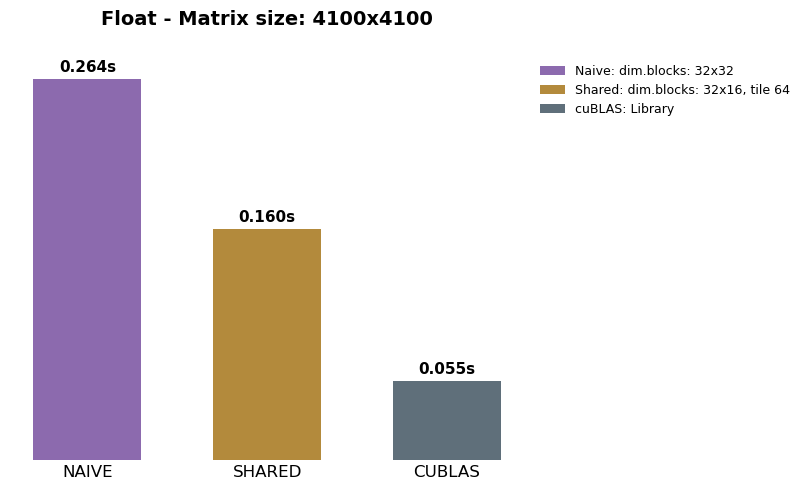

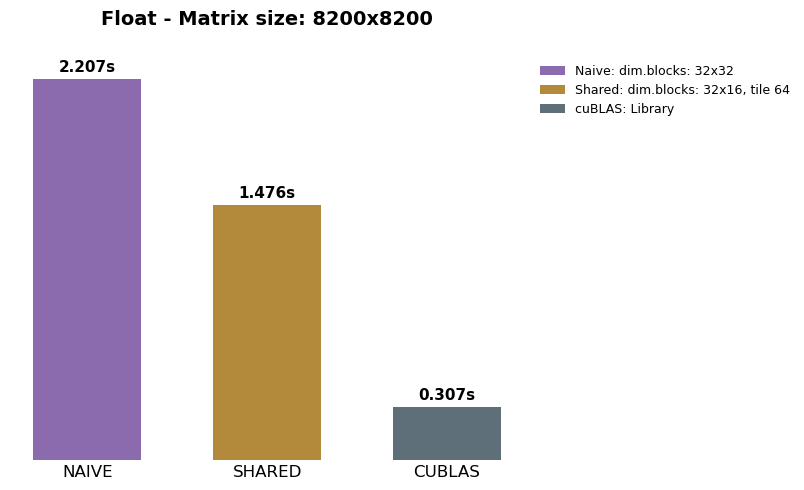

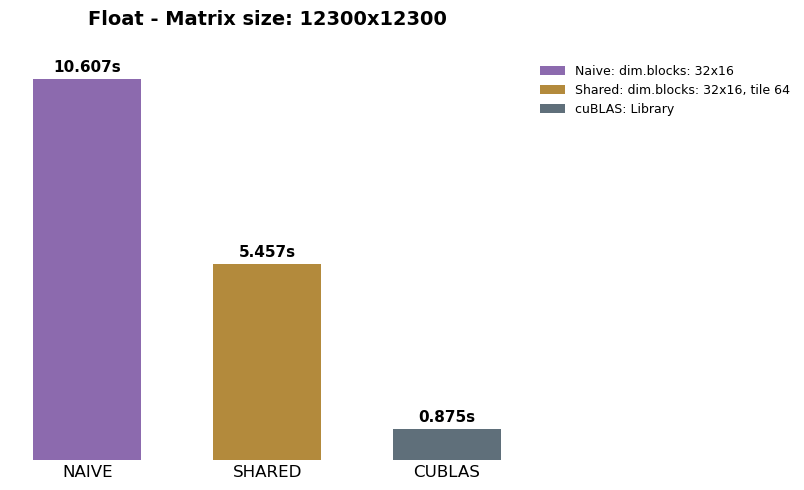

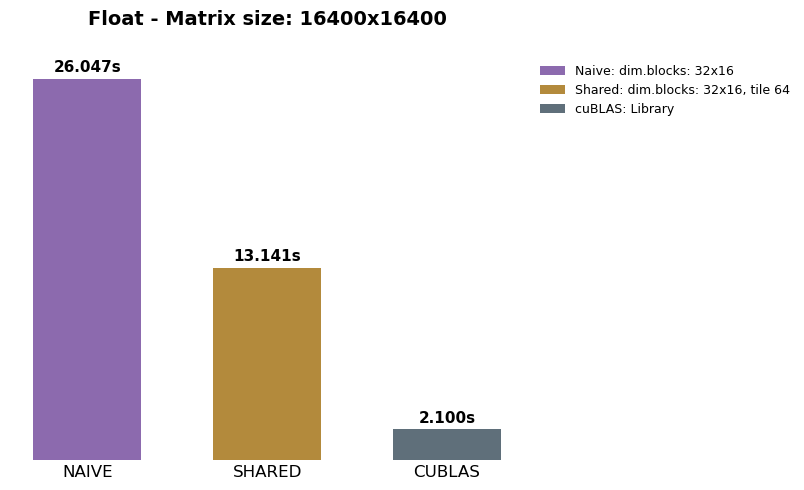

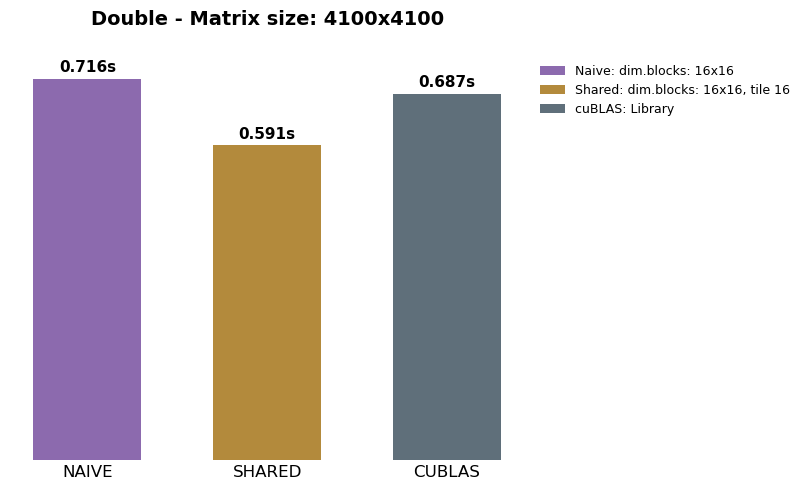

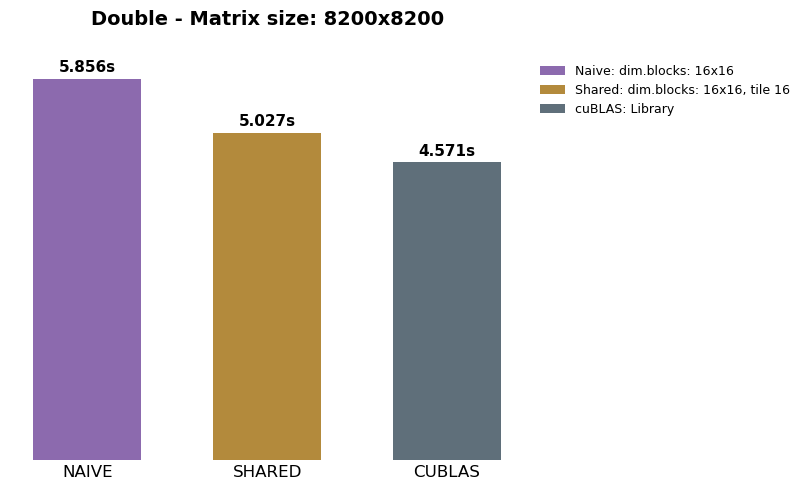

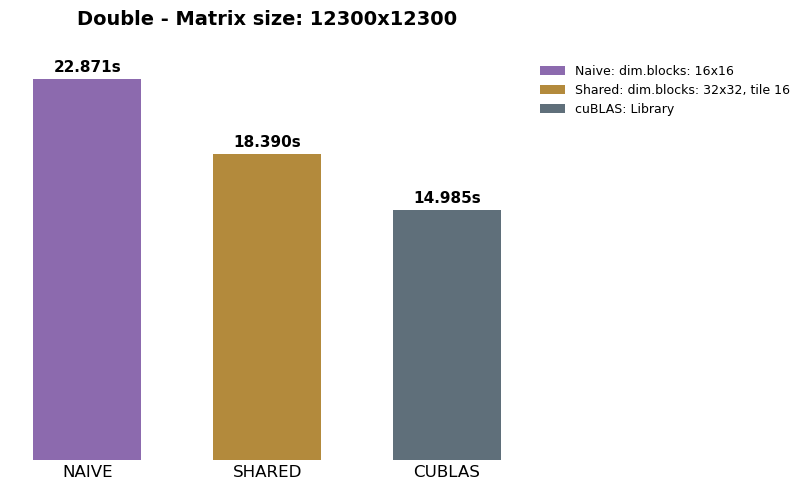

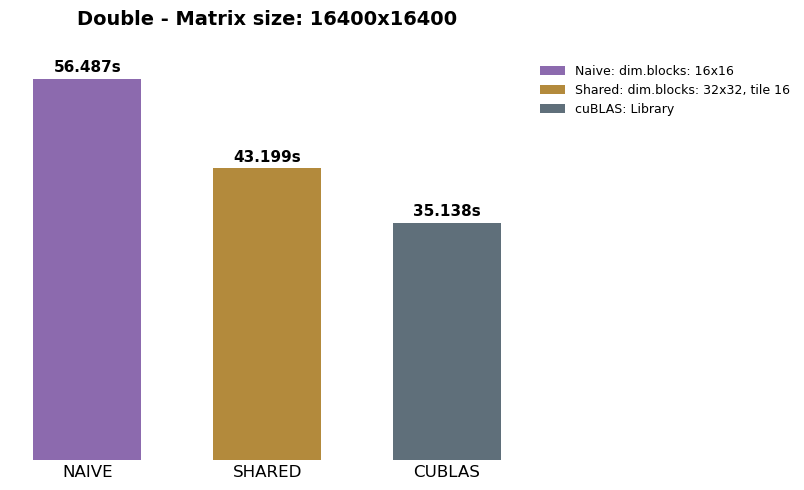

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CARICAMENTO DATI ---
# Caricamento con i nuovi nomi delle colonne forniti
df_sn = pd.read_csv("cuda_shared_naive_benchmark.csv")
df_cublas = pd.read_csv("cuda_cuBLAS_benchmark.csv")

# Standardizzazione cuBLAS
df_cublas['Algorithm'] = 'cuBLAS'
df_cublas['Config'] = 'Library'

# Standardizzazione Shared/Naive: creiamo la colonna 'Config' dai nuovi parametri
def build_config(row):
    if row['Algorithm'] == 'cuBLAS':
        return 'Library'
    # Se TileSize è presente e non nullo/vuoto
    if pd.notna(row.get('TileSize')) and str(row['TileSize']).strip() != "":
        return f"{row['BlockDim']}x{int(row['TileSize'])}"
    return str(row['BlockDim'])

df_sn['Config'] = df_sn.apply(build_config, axis=1)

# Unione dei dataset (usando Time_s come riferimento)
df = pd.concat([df_sn, df_cublas], ignore_index=True)

# Pulizia tipi e rinomina per comodità nel codice
df = df.rename(columns={'Time_s': 'Time(Seconds)'})
df["MatrixSize"] = pd.to_numeric(df["MatrixSize"], errors="coerce")
df["Time(Seconds)"] = pd.to_numeric(df["Time(Seconds)"], errors="coerce")

# --- 2. FUNZIONE FORMATTAZIONE LEGENDA ---
def format_config_legend(config_str):
    if config_str == "Library":
        return "Library"
    
    parts = str(config_str).lower().split('x')
    
    if len(parts) == 2:
        return f"dim.blocks: {parts[0]}x{parts[1]}"
    elif len(parts) == 3:
        return f"dim.blocks: {parts[0]}x{parts[1]}, tile {parts[2]}"
    
    return config_str

# --- 3. CONFIGURAZIONE PLOT ---
selected_sizes = [4100, 8200, 12300, 16400]
precisions = ["Float", "Double"]
colors = {"Naive": "#8C6AAE", "Shared": "#B38A3C", "cuBLAS": "#5F6F7A"}

def minimal_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.set_yticks([])
    ax.tick_params(axis="both", length=0)

# --- 4. GENERAZIONE GRAFICI ---
for prec in precisions:
    for N in selected_sizes:
        sub = df[(df["MatrixSize"] == N) & (df["Precision"] == prec)].copy()
        if sub.empty:
            continue

        best_rows = {}
        algos = ["Naive", "Shared", "cuBLAS"]
        for a in algos:
            algo_sub = sub[sub["Algorithm"] == a]
            if not algo_sub.empty:
                # Troviamo il tempo minimo per quell'algoritmo
                idx_min = algo_sub["Time(Seconds)"].idxmin()
                best_rows[a] = algo_sub.loc[idx_min]
            else:
                best_rows[a] = None

        times = [best_rows[a]["Time(Seconds)"] if best_rows[a] is not None else 0 for a in algos]
        
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(algos))
        bars = ax.bar(x, times, color=[colors[a] for a in algos], width=0.6)

        ax.set_title(f"{prec} - Matrix size: {N}x{N}", fontsize=14, fontweight='bold', pad=25)
        ax.set_xticks(x)
        ax.set_xticklabels([a.upper() for a in algos], fontsize=12)

        # Generazione Legenda
        handles = []
        labels = []
        for i, a in enumerate(algos):
            row = best_rows[a]
            if row is not None:
                formatted_cfg = format_config_legend(row['Config'])
                labels.append(f"{a}: {formatted_cfg}")
                handles.append(bars[i])
        
        ax.legend(
            handles, 
            labels, 
            frameon=False, 
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            fontsize=9,
            borderaxespad=0
        )

        # Annotazione tempi
        max_t = max(times) if any(times) else 0
        for bar, t in zip(bars, times):
            if t > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    t + (max_t * 0.01),
                    f"{t:.3f}s",
                    ha='center', va='bottom', fontsize=11, fontweight='bold'
                )

        minimal_style(ax)
        # Regoliamo il layout per far spazio alla legenda esterna
        plt.tight_layout(rect=[0, 0, 0.82, 1])
        plt.show()

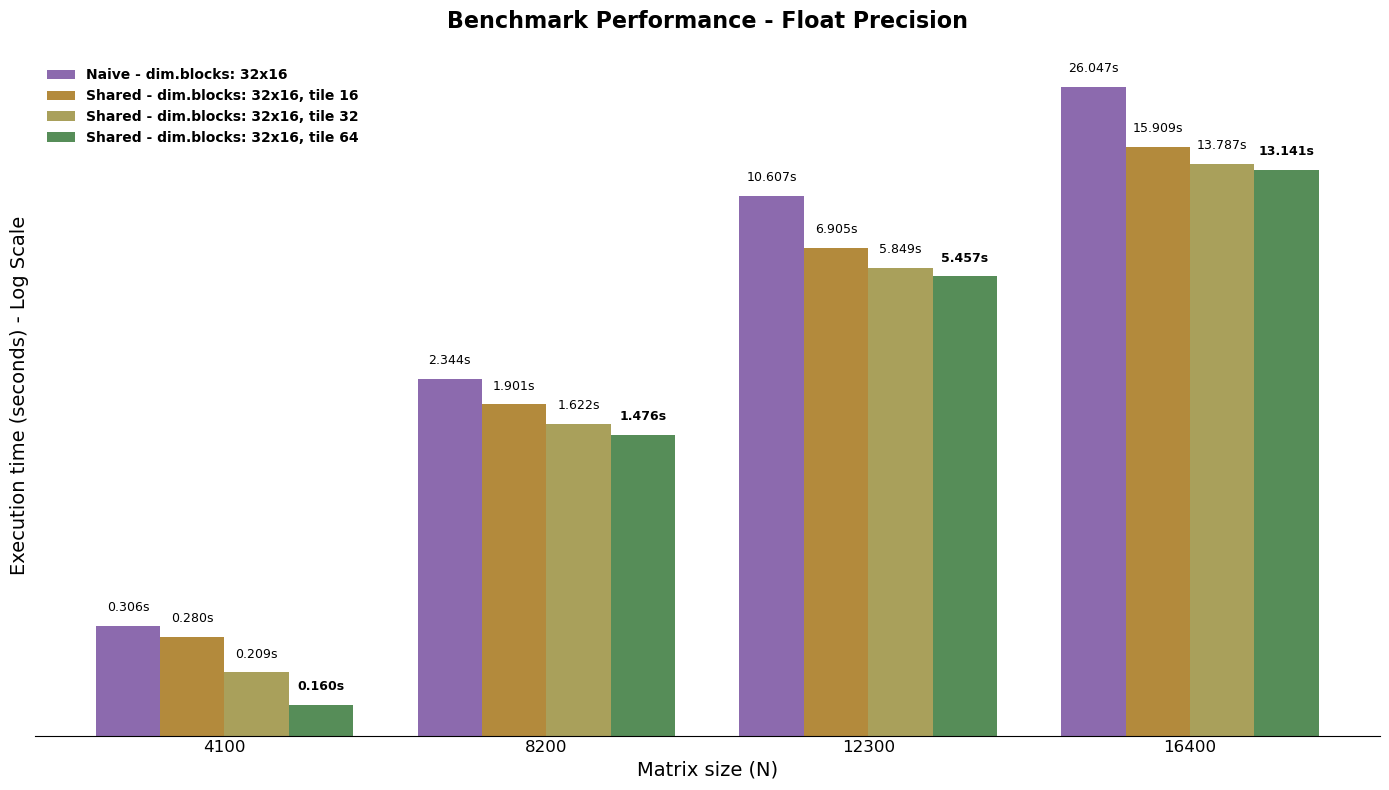

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPARAZIONE DATI ---
# Carichiamo il file (usa il nome corretto del tuo file)
df = pd.read_csv("cuda_shared_naive_benchmark.csv")

# Creazione colonna 'Config' sintetica per matchare la tua lista configs_to_plot
# Se TileSize è presente (Shared), facciamo BlockDim x TileSize, altrimenti solo BlockDim
df['Config'] = df.apply(
    lambda r: f"{r['BlockDim']}x{int(r['TileSize'])}" if pd.notna(r['TileSize']) else str(r['BlockDim']), 
    axis=1
)

# --- FILTRO PRECISIONE ---
# Scegli qui se vuoi il grafico per "Float" o "Double"
precision_target = "Float" 
df_plot = df[df["Precision"] == precision_target].copy()

selected_sizes = [4100, 8200, 12300, 16400]
configs_to_plot = [
    ("Naive", "32x16"),
    ("Shared", "32x16x16"),
    ("Shared", "32x16x32"),
    ("Shared", "32x16x64")
]

# Palette colori e Label
colors = ["#8C6AAE", "#B38A3C", "#A9A05B", "#568D58"]

def format_legend(algo, cfg):
    parts = cfg.split('x')
    if len(parts) == 2:
        return f"{algo} - dim.blocks: {parts[0]}x{parts[1]}"
    else:
        return f"{algo} - dim.blocks: {parts[0]}x{parts[1]}, tile {parts[2]}"

# --- 2. PLOTTING ---
x = np.arange(len(selected_sizes))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 8))

all_bars = []

for i, (algo, cfg) in enumerate(configs_to_plot):
    times = []
    for size in selected_sizes:
        # Usiamo Time_s come nel tuo nuovo CSV
        row = df_plot[(df_plot['MatrixSize'] == size) & 
                      (df_plot['Algorithm'] == algo) & 
                      (df_plot['Config'] == cfg)]
        
        if not row.empty:
            times.append(row['Time_s'].values[0])
        else:
            times.append(0)
    
    pos = x + (i - 1.5) * width
    rects = ax.bar(pos, times, width, label=format_legend(algo, cfg), color=colors[i])
    all_bars.append(rects)

# --- 3. STILE MINIMALISTA ---
ax.set_yscale("log")
ax.set_title(f"Benchmark Performance - {precision_target} Precision", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Matrix size (N)", fontsize=14)
ax.set_ylabel("Execution time (seconds) - Log Scale", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(selected_sizes, fontsize=12)

# Rimuoviamo i bordi e i tick Y per pulizia (come richiesto dal tuo stile)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(True) # Teniamo la base per riferimento
ax.tick_params(axis="y", which="both", left=False, labelleft=False)
ax.tick_params(axis="x", length=0)

# Legenda
ax.legend(frameon=False, loc="upper left", prop={"size": 10, "weight": "bold"})

# --- 4. ANNOTAZIONI (Bold per il minimo) ---
for i in range(len(selected_sizes)):
    group_values = []
    for j in range(len(configs_to_plot)):
        val = all_bars[j][i].get_height()
        if val > 0:
            group_values.append(val)
    
    min_val = min(group_values) if group_values else None
    
    for j in range(len(configs_to_plot)):
        bar = all_bars[j][i]
        val = bar.get_height()
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                val * 1.1, # Leggermente sopra la barra (offset logaritmico)
                f"{val:.3f}s",
                ha="center", va="bottom",
                fontsize=9,
                fontweight="bold" if val == min_val else "normal"
            )

plt.tight_layout()
plt.savefig(f"benchmark_summary_{precision_target.lower()}.png")
plt.show()

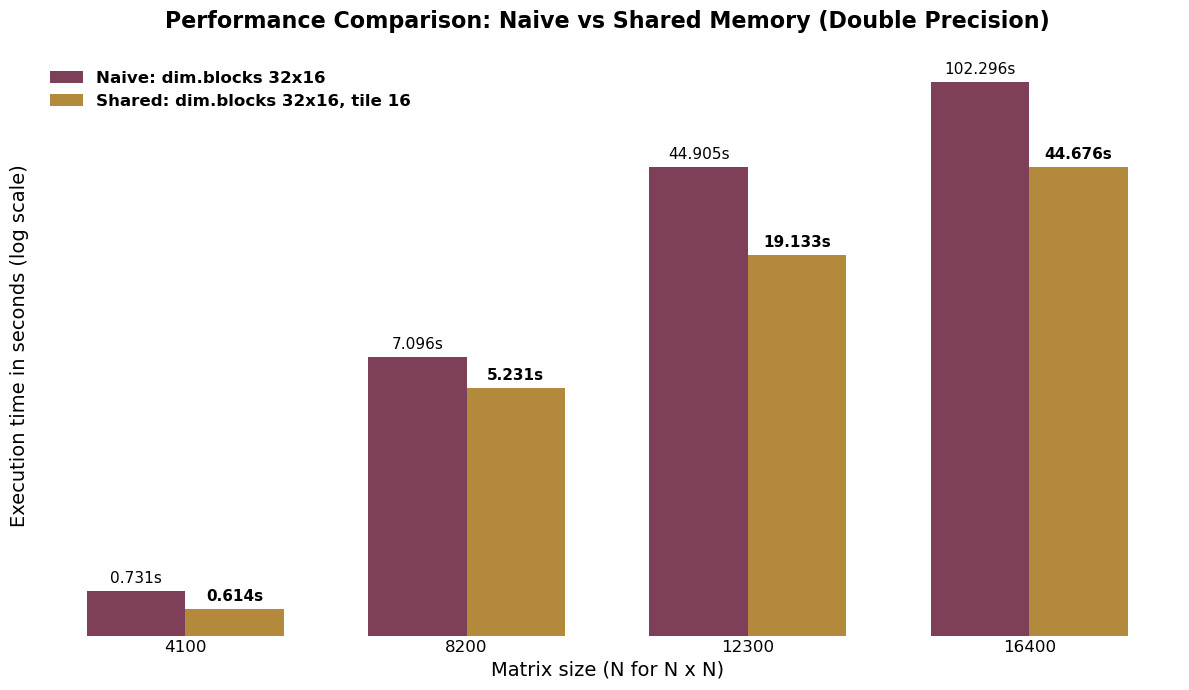

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPARAZIONE DATI ---
df_sn = pd.read_csv("cuda_shared_naive_benchmark.csv")

# Creazione colonna 'Config' sintetica per matchare la logica del plot
# Se TileSize esiste, crea 'BlockDimxTileSize', altrimenti solo 'BlockDim'
df_sn['Config'] = df_sn.apply(
    lambda r: f"{r['BlockDim']}x{int(r['TileSize'])}" if pd.notna(r['TileSize']) else str(r['BlockDim']), 
    axis=1
)

# Filtro: Solo DOUBLE
df_d = df_sn[df_sn["Precision"] == "Double"].copy()
selected_sizes = [4100, 8200, 12300, 16400]

# Configurazioni richieste
# Naive: 32x16
# Shared: 32x16x16
configs_to_plot = [
    ("Naive", "32x16"),
    ("Shared", "32x16x16")
]

colors = ["#7E3F59", "#B38A3C"] # Amaranto per Naive, Oro per Shared

# --- 2. GENERAZIONE PLOT ---
x = np.arange(len(selected_sizes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

all_bars = []

for i, (algo, cfg) in enumerate(configs_to_plot):
    times = []
    for size in selected_sizes:
        # Check colonna: Time_s invece di Time(Seconds)
        row = df_d[(df_d['MatrixSize'] == size) & 
                   (df_d['Algorithm'] == algo) & 
                   (df_d['Config'] == cfg)]
        if not row.empty:
            times.append(row['Time_s'].values[0])
        else:
            times.append(0)
    
    pos = x + (i - 0.5) * width
    label_text = f"{algo}: dim.blocks 32x16" + (", tile 16" if i==1 else "")
    rects = ax.bar(pos, times, width, label=label_text, color=colors[i], edgecolor="none")
    all_bars.append(rects)

# Minimal Style (Log Scale)
ax.set_yscale("log")
ax.set_title("Performance Comparison: Naive vs Shared Memory (Double Precision)", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
ax.set_ylabel("Execution time in seconds (log scale)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(selected_sizes, fontsize=12)

# Pulizia estetica
ax.set_yticks([])
ax.tick_params(axis="y", which="both", left=False, labelleft=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.grid(False)

# Legenda
ax.legend(frameon=False, loc="upper left", prop={"size": 12, "weight": "bold"})

# Annotazioni e Bold per il minimo
for i in range(len(selected_sizes)):
    v1 = all_bars[0][i].get_height()
    v2 = all_bars[1][i].get_height()
    
    # Calcolo del minimo per il grassetto (solo se entrambi i valori esistono)
    valid_vals = [v for v in [v1, v2] if v > 0]
    min_val = min(valid_vals) if valid_vals else None
    
    for bar, val in zip([all_bars[0][i], all_bars[1][i]], [v1, v2]):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                val * 1.05, # Offset moltiplicativo per scala logaritmica
                f"{val:.3f}s",
                ha="center", va="bottom",
                fontsize=11,
                fontweight="bold" if val == min_val else "normal"
            )

plt.tight_layout()
plt.show()